# Car Price Prediction — Model Building & Evaluation

Trains 7 regressors, runs cross-validation, plots residuals, and tunes the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from utils import (
    evaluate_model, plot_residuals, plot_pred_vs_actual,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/car_data_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (299, 10)


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Kms_per_Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,4500.000000,0,1,0,1
1,4.75,9.54,43000,0,7,6142.857143,1,0,0,1
2,7.25,9.85,6900,0,3,2300.000000,0,1,0,1
3,2.85,4.15,5200,0,9,577.777778,0,1,0,1
4,4.60,6.87,42450,0,6,7075.000000,1,0,0,1


## 2. Train / Test Split & Scaling

In [3]:
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 9
Target stats:
count    299.00
mean       4.59
std        4.98
min        0.10
25%        0.85
50%        3.51
75%        6.00
max       35.00
Name: Selling_Price, dtype: float64
Train: (239, 9) Test: (60, 9)


## 3. Train 7 Regressors

In [4]:
results = []
models = {}


  Linear Regression
  MAE   : 1.5126
  RMSE  : 2.6020
  R2    : 0.7373
  MAPE  : 1.6937


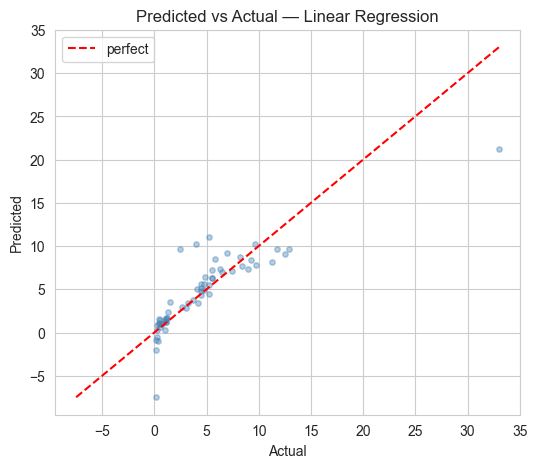

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()


  Ridge
  MAE   : 1.5133
  RMSE  : 2.5921
  R2    : 0.7393
  MAPE  : 1.6671


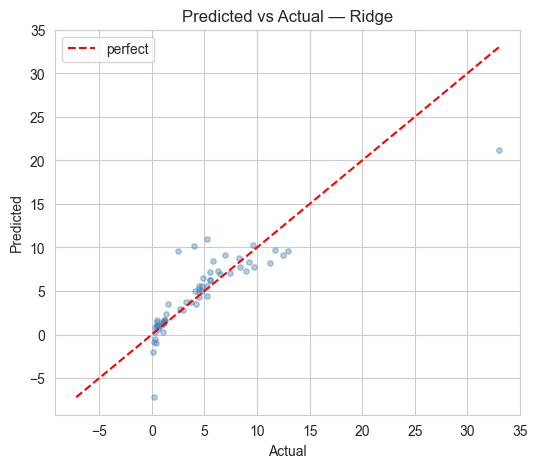

In [6]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()


  Lasso
  MAE   : 1.4388
  RMSE  : 2.4715
  R2    : 0.7630
  MAPE  : 1.1376


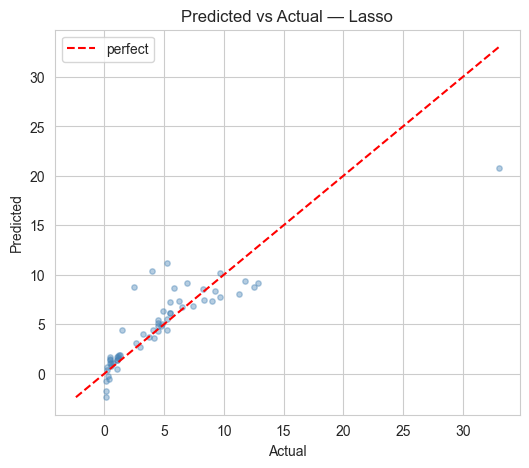

In [7]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()


  Decision Tree
  MAE   : 1.0523
  RMSE  : 2.0379
  R2    : 0.8389
  MAPE  : 0.3135


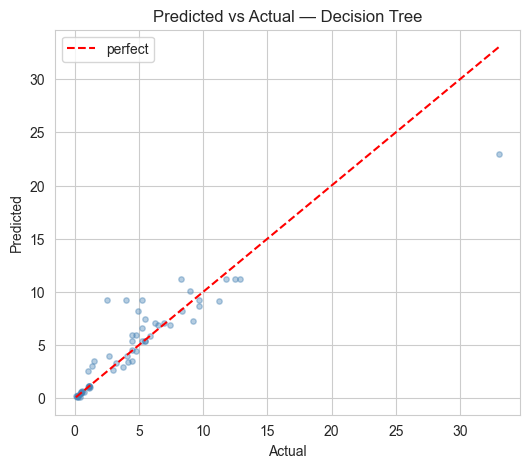

In [8]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()


  Random Forest
  MAE   : 1.4932
  RMSE  : 3.5592
  R2    : 0.5085
  MAPE  : 0.3856


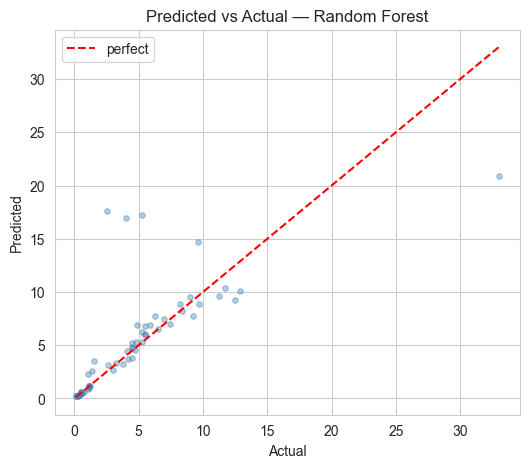

In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()

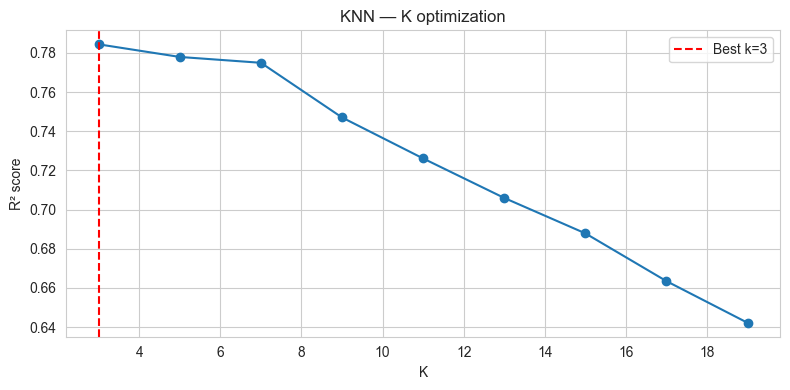


  KNN (k=3)
  MAE   : 1.2836
  RMSE  : 2.3572
  R2    : 0.7844
  MAPE  : 1.0309


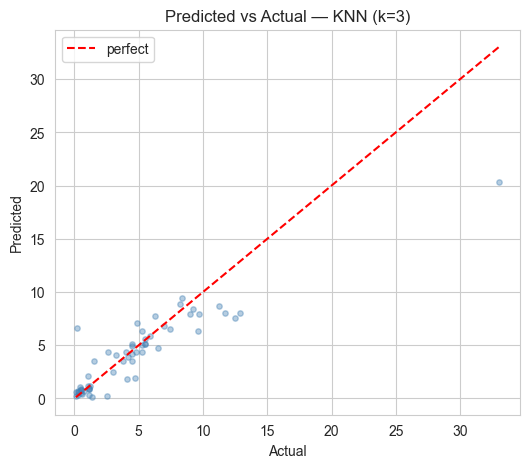

In [10]:
k_range = range(3, 21, 2)
from sklearn.metrics import r2_score
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4)); plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, knn_label); plt.show()


  Gradient Boosting
  MAE   : 1.2406
  RMSE  : 2.7337
  R2    : 0.7100
  MAPE  : 0.3410


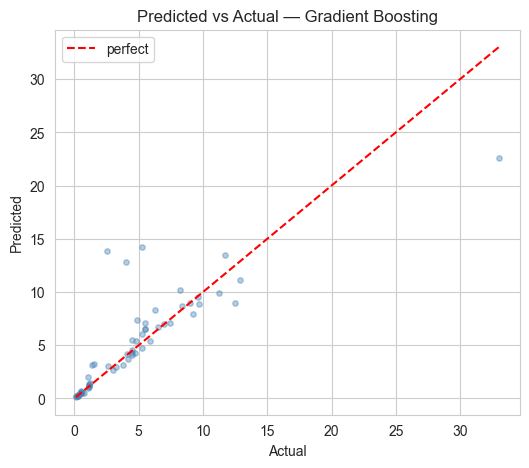

In [11]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting'); plt.show()

## 4. Feature Importance — Tree Models

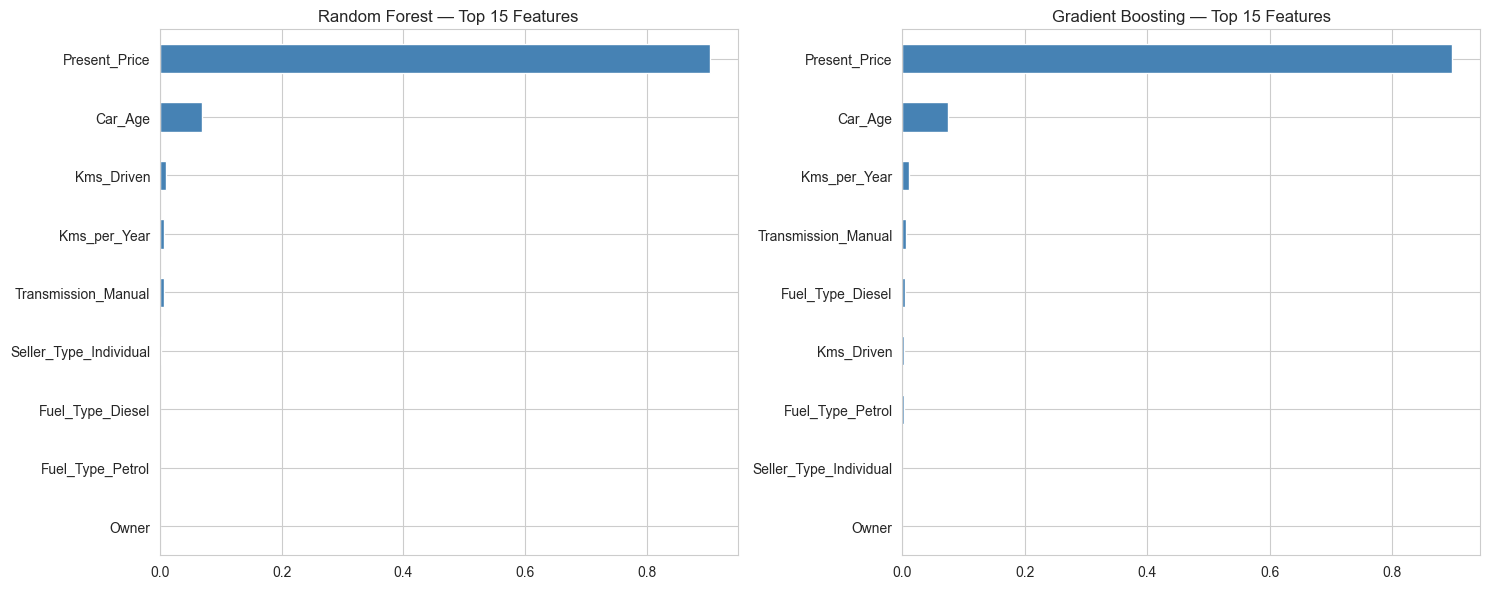

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()

## 5. Model Comparison

In [13]:
comparison = compare_models(results)
comparison

,Model,MAE,RMSE,R2,MAPE
0,Decision Tree,1.052292,2.037933,0.838857,0.313528
1,KNN (k=3),1.283556,2.357248,0.784404,1.030873
2,Lasso,1.438846,2.471527,0.762993,1.137604
3,Ridge,1.513302,2.592090,0.739306,1.667136
4,Linear Regression,1.512592,2.601961,0.737317,1.693719
5,Gradient Boosting,1.240635,2.733709,0.710042,0.341010
6,Random Forest,1.493211,3.559233,0.508478,0.385556


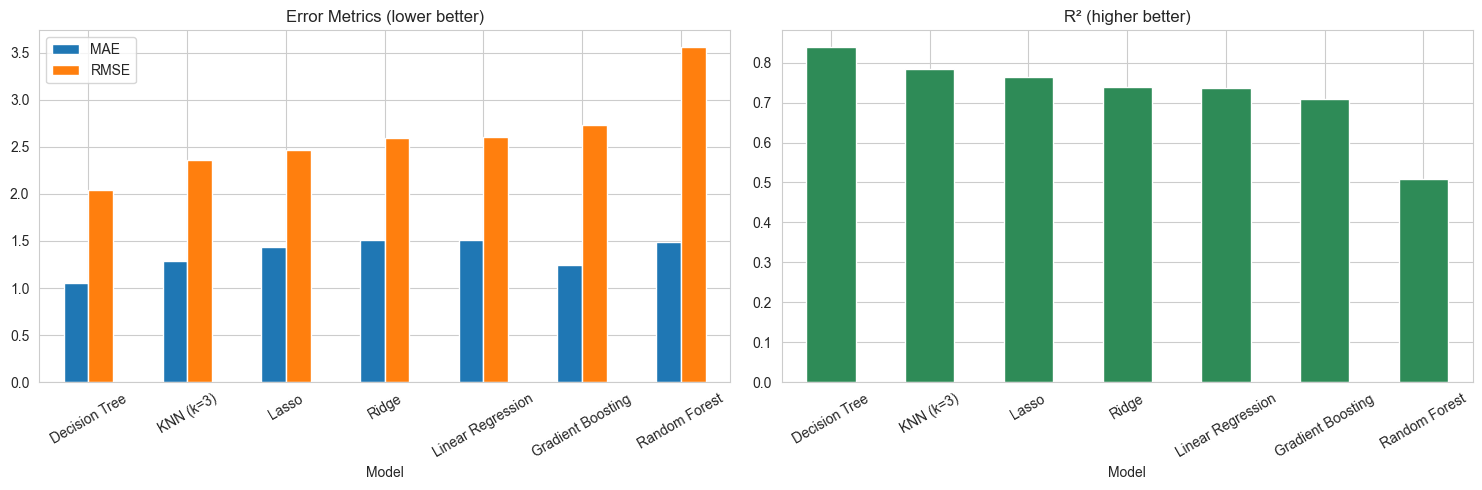

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 6. 5-Fold Cross-Validation

In [15]:
cv_scores = {}
X_full_scaled = scaler.fit_transform(X)
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='r2', n_jobs=-1)
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear Regression         mean R² = -2322397983215386644971520.0000 (+/- 4644795966430773289943040.0000)


Ridge                     mean R² = -21.4235 (+/- 44.3739)
Lasso                     mean R² = -21.1167 (+/- 43.8265)


Decision Tree             mean R² = 0.0671 (+/- 1.3577)


Random Forest             mean R² = 0.3178 (+/- 1.0854)
KNN (k=3)                 mean R² = -13.5998 (+/- 28.6793)


Gradient Boosting         mean R² = 0.0680 (+/- 1.6001)


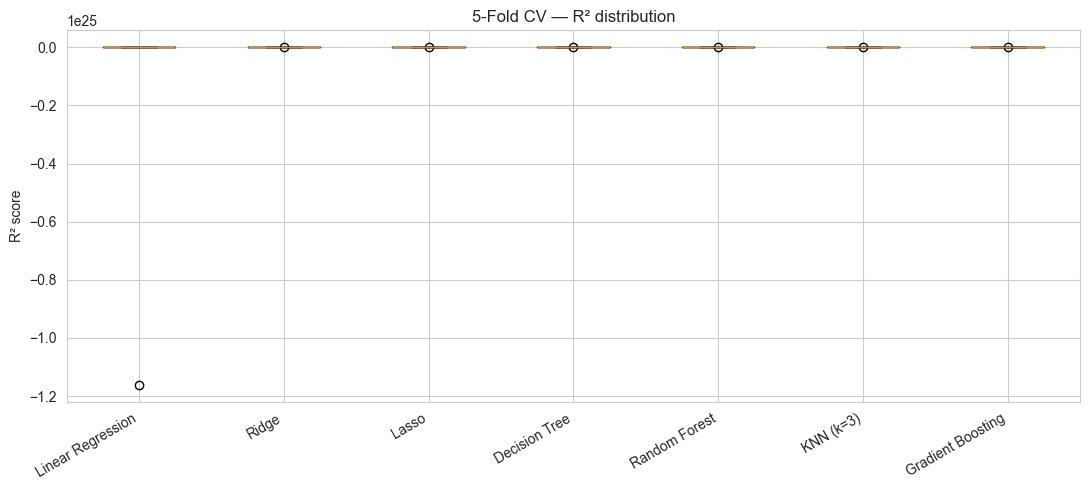

In [16]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('5-Fold CV — R² distribution'); plt.tight_layout(); plt.show()

## 7. Residuals — Best Model

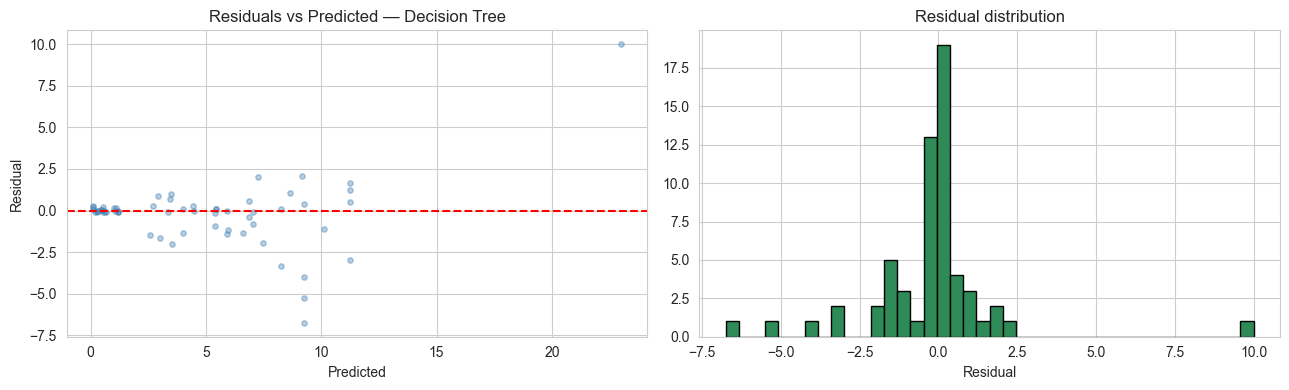

In [17]:
best_model_name = comparison.iloc[0]['Model']
kind, best_pre = models[best_model_name]
Xt = X_test_scaled if kind == 'scaled' else X_test
y_pred_best = best_pre.predict(Xt)
plot_residuals(y_test, y_pred_best, best_model_name); plt.show()

## 8. Hyperparameter Tuning — Best Performer

Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV R²: 0.8669

  Random Forest (Tuned)
  MAE   : 1.4367
  RMSE  : 3.4338
  R2    : 0.5425
  MAPE  : 0.3870


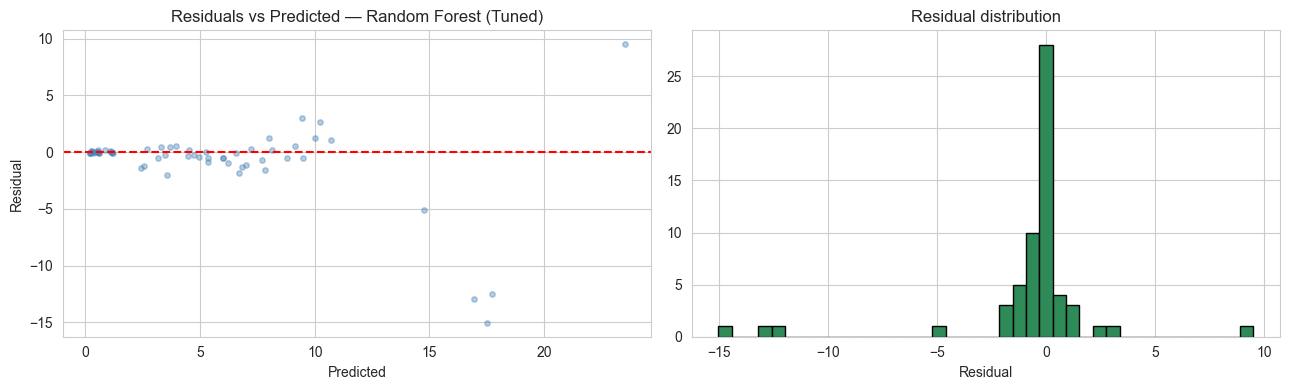

In [18]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
}
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Random Forest (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Random Forest (Tuned)'); plt.show()

## 9. Tuned Model — Feature Importance

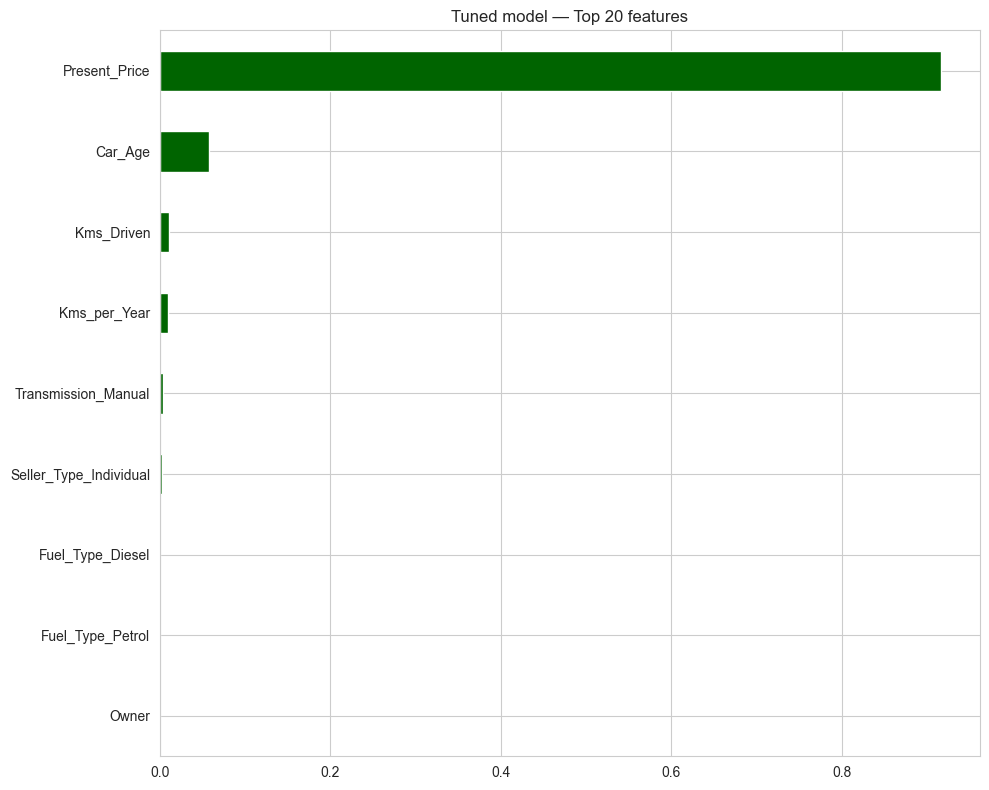

In [19]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()

## 10. Sample Prediction

In [20]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out

,Predicted,Actual,AbsError
0,9.50,8.99,0.51
1,8.12,8.35,0.23
2,0.46,0.45,0.01
3,7.20,7.45,0.25
4,17.71,5.25,12.46


## 11. Final Summary

In [21]:
final = compare_models(results)
final

,Model,MAE,RMSE,R2,MAPE
0,Decision Tree,1.052292,2.037933,0.838857,0.313528
1,KNN (k=3),1.283556,2.357248,0.784404,1.030873
2,Lasso,1.438846,2.471527,0.762993,1.137604
3,Ridge,1.513302,2.592090,0.739306,1.667136
4,Linear Regression,1.512592,2.601961,0.737317,1.693719
5,Gradient Boosting,1.240635,2.733709,0.710042,0.341010
6,Random Forest (Tuned),1.436668,3.433809,0.542509,0.387005
7,Random Forest,1.493211,3.559233,0.508478,0.385556


### Key Takeaways

- Car Price Prediction: regression on `Selling_Price`.
- 7 regressors + 1 tuned variant evaluated on MAE / RMSE / R² / MAPE.
- Tree-based models highlight the most predictive features.
- Predicted-vs-actual scatter plots reveal where models systematically over/underestimate.

### Next Steps

- Try gradient boosters (XGBoost, LightGBM) for further gains.
- Apply log-transform on skewed targets and re-fit.
- Add domain-specific feature engineering.